# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonians

$$
\begin{equation}
    H_{\text{free}}=\sum_{q_x, \sigma} \frac{\hbar^2 q_x^2}{2m_\mathrm{Yb}}c_{\sigma}^\dagger(q_x) c_{\sigma}(q_x)
\end{equation}
$$

$$
\begin{equation}
    H_{\text{loss}}=-\frac{1}{L}\frac{i}{2}\gamma\sum_{k, k', q}c_\downarrow^\dagger(k'+q)c_\uparrow^\dagger(k-q)c_\uparrow(k)c_\downarrow(k')
\end{equation}
$$

$q_x=[-k_{\text{cutoff}}, ..., 2k_0, -k_0, 0, k_0, 2k_0, ..., k_{\text{cutoff}}]$ where $k_0 = \frac{2\pi}{L}$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\gamma/E_r =\ ?$
  - $T_2 = \ ?$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(k_1)c_{\sigma_2}^\dagger(k_2)\cdots c_{\sigma_n}^\dagger(k_n)\ket{0}:\sigma_j=\uparrow,\downarrow, k_1<k_2<\cdots<k_n, |k_j|<k_\text{cutoff}, k_j\in (2\pi / L) \mathbb Z\}$$
$$[H]_{\mathcal{B}}$$

In [1]:
# !unzip opalg

imports

In [2]:
import time
import math
import json
import os
import itertools

import numpy as np
import scipy

import tqdm
import matplotlib.pyplot as plt
import gc

from einops import einsum, rearrange, reduce, pack

from quant_mech import hilbert, ybsoc
from quant_mech.plot_utils import (
    plot_numbers,
    generate_k_labels
)

drive mount & save data path

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
DATA_ROOT = r"C:\workspace\yb-soc-two-body-loss\data\temp\lindblad_test"
os.makedirs(DATA_ROOT, exist_ok=True)

## System Definition

In [5]:
t_r = 0.1129 # ms

In [6]:
n_momentum_points = 13
n_particles = 5

hbar = 1.
m_Yb = 1.

k_r = 1.0
delta = 4.0
omega_R = 3.5

k0 = 0.5
L = 2 * np.pi / k0
gamma = 0.36

T2 = 0.52 / t_r

In [7]:
hilb = hilbert.PBCBox1D(
    L=L,
    n_momentum_points=n_momentum_points,
    n_particles=list(range(n_particles, -1, -2))
)

## Initial State Preparation

In [8]:
ks = np.array(hilb.momentums)
momentum_modes = tuple(np.argsort(ks ** 2)[:n_particles].tolist())
pure = hilb.get_momentum_eigenstate(
    tuple((mode, 1) for mode in momentum_modes)
)

mixture = hilb.get_momentum_eigenstate(
    tuple((mode, (-1) ** idx) for idx, mode in enumerate(momentum_modes))
)

prob_up = 1 - 0.31844
theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
phi = 0

alpha = np.cos(theta / 2)
beta = np.exp(1j * phi) * np.sin(theta / 2)

spin_amps = {
    1: alpha,
    -1: beta
}
spins = list(spin_amps.keys())

superposed = np.zeros_like(mixture)
for spin_config in itertools.product(spins, repeat=n_particles):
    amp = np.prod([spin_amps[s] for s in spin_config])
    basis_config = tuple(
        (mode, spin) for mode, spin in zip(momentum_modes, spin_config)
    )
    basis = hilb.get_momentum_eigenstate(basis_config)
    superposed = superposed + amp * basis

In [9]:
k_tick_labels = generate_k_labels(n_momentum_points, k0)

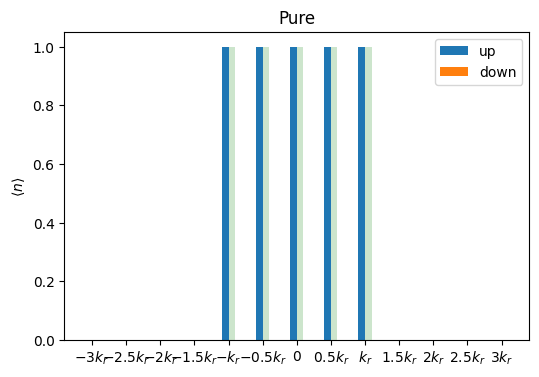

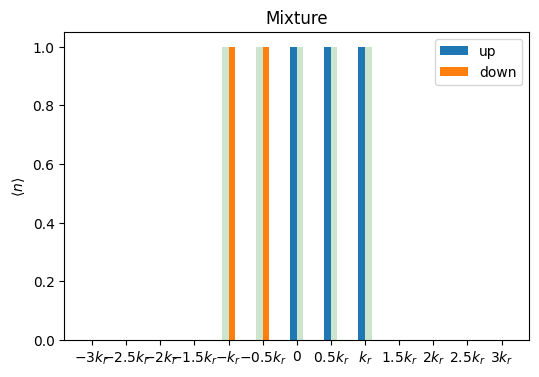

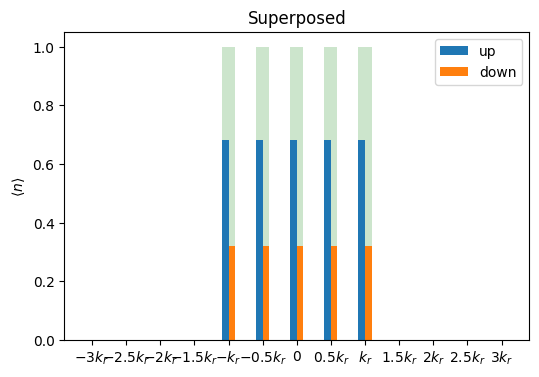

In [10]:
pure_nums, mixture_nums, superposed_nums = hilb.momentum_expected_numbers(np.stack([pure, mixture, superposed]))
plot_numbers(*pure_nums, tick_labels=k_tick_labels, title="Pure")
plot_numbers(*mixture_nums, tick_labels=k_tick_labels, title="Mixture")
plot_numbers(*superposed_nums, tick_labels=k_tick_labels, title="Superposed")

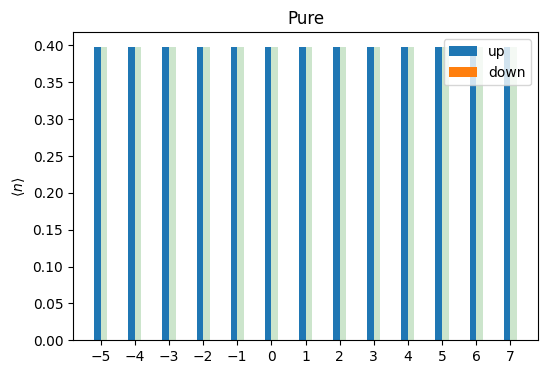

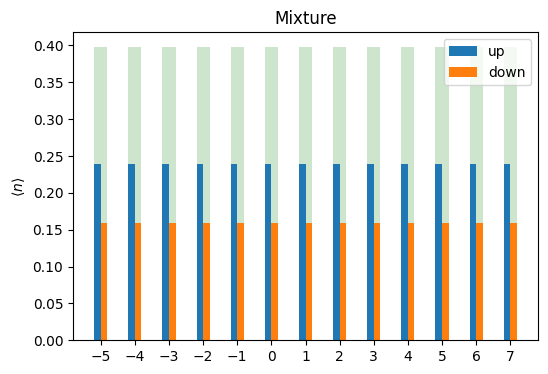

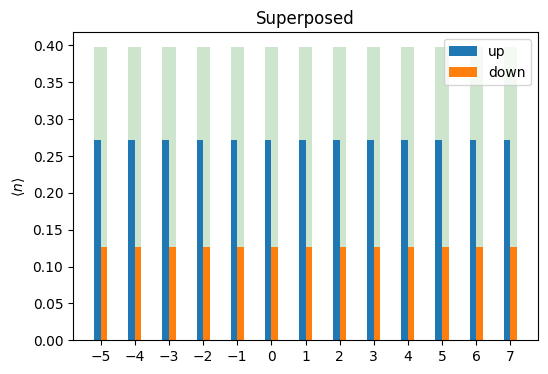

In [11]:
pure_nums, mixture_nums, superposed_nums = hilb.position_expected_numbers(np.stack([pure, mixture, superposed]))
plot_numbers(*pure_nums, title="Pure")
plot_numbers(*mixture_nums, title="Mixture")
plot_numbers(*superposed_nums, title="Superposed")

In [12]:
soc_hamiltonian = ybsoc.sparse_hamiltonian_scipy_csr(
    hilb,
    hbar=hbar,
    k_r=k_r,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    U=0.0
)

In [13]:
E_gs, psi_gs = scipy.sparse.linalg.eigsh(
    soc_hamiltonian,
    k=1,
    which='SA',
    tol=1e-6,
    return_eigenvectors=True
)

In [14]:
soc_ground = psi_gs[:, 0]

In [15]:
# initial_state = pure
# initial_state = mixture
# initial_state = superposed

initial_state = soc_ground

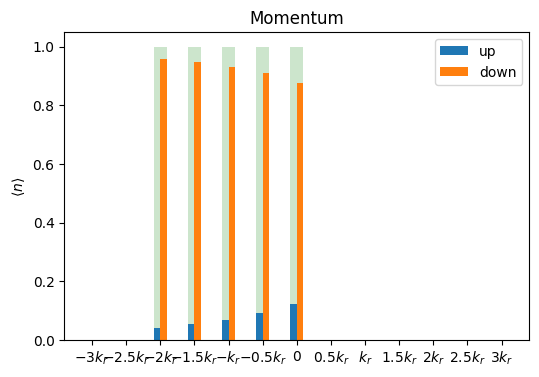

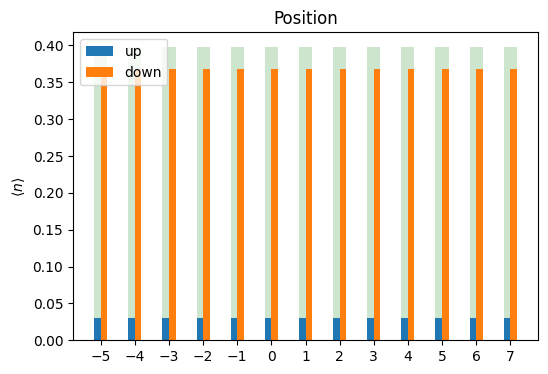

In [16]:
initial_nums = hilb.momentum_expected_numbers(initial_state)
plot_numbers(*initial_nums, tick_labels=k_tick_labels, title="Momentum")

initial_nums = hilb.position_expected_numbers(initial_state)
plot_numbers(*initial_nums, title="Position")

## Two-body loss simulation by quantum jump method

- Hamiltonians
\begin{gather}
H_{\text{free}}=\sum_{q_x, \sigma} \frac{\hbar^2 q_x^2}{2m_\mathrm{Yb}}c_{\sigma}^\dagger(q_x) c_{\sigma}(q_x),\\
H_{\text{loss}}=-\frac{i\gamma\hbar}{2V}\sum_{k, k', q} c_{\downarrow}^\dagger(k'+q) c_{\uparrow}^\dagger(k-q)c_{\uparrow}(k)c_{\downarrow}(k'),\\
\end{gather}


- Lindblad master equation
\begin{align}
\frac{d\rho}{dt} &=-\frac{i}{\hbar} [H_\text{free}, \rho] + \int dx \left(L_x\rho L_x^\dagger -\frac{1}{2}\{L_x^\dagger L_x,\rho\}\right)\\
&=-\frac{i}{\hbar} [H_\text{free}, \rho] + \sum_q \left(\tilde{L}_q\rho \tilde{L}_q^\dagger -\frac{1}{2}\{\tilde{L}_q^\dagger \tilde{L}_q,\rho\}\right)
\end{align}


Two-body loss channels:
\begin{equation}
	L_x=\sqrt{\gamma} c_{\uparrow}(x) c_{\downarrow}(x),\quad \tilde{L}_q=\sqrt{\frac{\gamma}{V}}\sum_{k_1+k_2=q}c_{\uparrow}(k_q) c_{\downarrow}(k_2)
\end{equation}



- Master equation with decoherence
\begin{equation}
	\frac{d\rho}{dt} =-\frac{i}{\hbar} [H_\text{free}, \rho] + \underbrace{\sum_q \left(\tilde{L}_q\rho \tilde{L}_q^\dagger -\frac{1}{2}\{\tilde{L}_q^\dagger \tilde{L}_q,\rho\}\right)}_{\text{two-body loss}} + \underbrace{\sum_{j=1}^{\dim \mathcal H}\left(M_j\rho M_j^\dagger - \frac{1}{2}\{M_j^\dagger M_j,\ \rho\}\right)}_{\text{decoherence}}
\end{equation}


Decoherence channels:
\begin{gather}
M_j=\sqrt{\frac{1}{T_2}}\ket{j}\bra{j} \quad(\ket{j}\in\mathcal{B}), \\
\mathcal{B}= \{c_{\sigma_1}^\dagger(k_1)c_{\sigma_2}^\dagger(k_2)\cdots c_{\sigma_n}^\dagger(k_n)\ket{0}:\sigma_j=\uparrow,\downarrow, k_1<k_2<\cdots<k_n, |k_j|<k_\text{cutoff}, k_j\in (2\pi / L) \mathbb Z\}
\end{gather}


- non-hermitian evolution part and jump part
\begin{equation}
	\frac{d\rho}{dt}=\underbrace{-\frac{i}{\hbar} [H_\text{eff}\rho - \rho H_\text{eff}^\dagger]}_{\text{non-hermitian evolution}} + \underbrace{\sum_{q} \tilde{L}_q\rho \tilde{L}_q^\dagger}_{\text{loss jumps}} + \underbrace{\sum_{j=1}^{\dim \mathcal H}M_j\rho M_j^\dagger}_{\text{decoherence jumps}}
\end{equation}


Effective hamiltonian:
\begin{equation}
    H=H_\text{free} + H_\text{loss} -\frac{i\hbar}{2T_2}
\end{equation}



- $T_2 = 0.4 \,\mathrm{ms}$

### simulation settings

In [17]:
t0 = 0
t1 = 2.0 / 0.1129
n_timesteps = 101
save_at = np.linspace(t0, t1, n_timesteps)
step_size = save_at[1] - save_at[0]

n_trajectories = 256
batch_size = 32
jumps_per_step = 2 # try 200 jump total

assert n_trajectories % batch_size == 0

In [18]:
num_batches = n_trajectories // batch_size
total_n_steps = (n_timesteps - 1) * jumps_per_step
delta_t = (t1 - t0) / total_n_steps

loss_channels = ybsoc.lindblad_two_body_loss_scipy_csr(
    hilb, gamma, reduced_rows=True
)
subspace_dim = hilb.space_dim - math.comb(hilb.num_single_particle_states, hilb.n_particles[-1])
n_loss_channels = len(loss_channels)
stacked_loss_op = scipy.sparse.vstack(loss_channels, format='csr')

del loss_channels
gc.collect()

hilb_dim = hilb.space_dim
H_eff = ybsoc.sparse_hamiltonian_scipy_csr(
    hilb,
    hbar=hbar,
    k_r=0.0,
    m_Yb=m_Yb,
    delta=0.0,
    omega_R=0.0,
    U=-(1/2) * 1j * gamma * hbar
)
H_eff = H_eff - (1j * hbar) / (2 * T2) * scipy.sparse.identity(hilb_dim, format='csr')

In [ ]:
up_nums_momentum = np.zeros((n_timesteps, n_momentum_points))
down_nums_momentum = np.zeros((n_timesteps, n_momentum_points))
n_position_points = n_momentum_points
up_nums_position = np.zeros((n_timesteps, n_position_points))
down_nums_position = np.zeros((n_timesteps, n_position_points))

for i_batch in range(num_batches):
    psi_batched = np.repeat(initial_state[:, np.newaxis], batch_size, axis=1) # prepare batched states
    mask = np.full((batch_size,), 1.)
    zeros = np.zeros((batch_size,))
    
    psis = psi_batched.T # (n, b) => (b, n)
    nums = hilb.momentum_expected_numbers(psis) # (b, L)
    up_mom, down_mom = rearrange(nums, "b s k -> s b k")
    up_nums_momentum[0, :] += np.sum(up_mom * mask[:, np.newaxis], axis=0)
    down_nums_momentum[0, :] += np.sum(down_mom * mask[:, np.newaxis], axis=0)
    nums = hilb.position_expected_numbers(psis)
    up_pos, down_pos = rearrange(nums, "b s x -> s b x")
    up_nums_position[0, :] += np.sum(up_pos * mask[:, np.newaxis], axis=0)
    down_nums_position[0, :] += np.sum(down_pos * mask[:, np.newaxis], axis=0)
    
    for iteration in tqdm.trange(total_n_steps, desc=f"batch {i_batch}: {(i_batch+1) * batch_size}/{n_trajectories} Trajectories", leave=False):
        # non-hermitian evolution
        psi_batched = scipy.sparse.linalg.expm_multiply(
            -1j * H_eff * delta_t / hbar,
            psi_batched
        )
        
        # apply loss operator
        loss_jumped = rearrange(
            stacked_loss_op @ psi_batched, 
            "(channels state) batch -> channels state batch", 
            channels=n_loss_channels
        )
        
        # calculate jump probabilities
        loss_jump_probs = np.linalg.norm(loss_jumped, axis=1) ** 2 * delta_t # channels state batch -> channels batch
        dephase_jump_probs = (1 / T2) * (np.abs(psi_batched) ** 2) * delta_t # (hdim, batch)
        no_jump_probs = 1 - (np.sum(loss_jump_probs, axis=0, keepdims=True) + np.sum(dephase_jump_probs, axis=0, keepdims=True))
        jump_probs, _ = pack(
            [loss_jump_probs, dephase_jump_probs, no_jump_probs],
            "* batch"
        )
        cum_probs = np.cumsum(jump_probs, axis=0) # (channels, batch)
        rand_vals = np.random.rand(batch_size)
        # argmax trick: find the first channel where cumulative probability exceeds random value
        jump_indices = np.argmax((cum_probs.T > rand_vals[:, np.newaxis]), axis=1) # (batch,)
        
        # apply jump
        for b_idx, jump_idx in enumerate(jump_indices):
            if jump_idx < n_loss_channels:
                psi_batched[:subspace_dim, b_idx] = loss_jumped[jump_idx, :, b_idx]
                psi_batched[subspace_dim:, b_idx] = 0
            elif jump_idx < n_loss_channels + hilb_dim:
                psi_batched[:, b_idx] = 0
                psi_batched[jump_idx - n_loss_channels, b_idx] = 1
        
        # normalization
        psi_batched /= np.linalg.norm(psi_batched, axis=0, keepdims=True)
        
        # calculate obaservables
        if (iteration + 1) % jumps_per_step != 0:
            continue
        
        i = (iteration + 1) // jumps_per_step
        psis = psi_batched.T # (n, b) => (b, n)
        
        nums = hilb.momentum_expected_numbers(psis) # (b, L)
        up_mom, down_mom = rearrange(nums, "b s k -> s b k")
        up_nums_momentum[i, :] += np.sum(up_mom * mask[:, np.newaxis], axis=0)
        down_nums_momentum[i, :] += np.sum(down_mom * mask[:, np.newaxis], axis=0)
        
        if i < n_timesteps - 1:
            continue
        
        nums = hilb.position_expected_numbers(psis)
        up_pos, down_pos = rearrange(nums, "b s x -> s b x")
        up_nums_position[i, :] += np.sum(up_pos * mask[:, np.newaxis], axis=0)
        down_nums_position[i, :] += np.sum(down_pos * mask[:, np.newaxis], axis=0)
        
        gc.collect()

up_nums_momentum /= n_trajectories
down_nums_momentum /= n_trajectories
up_nums_position /= n_trajectories
down_nums_position /= n_trajectories

batch 0: 32/256 Trajectories:   1%|          | 2/200 [00:03<06:23,  1.94s/it]

In [ ]:
total_up_decoherence = np.sum(up_nums_momentum, axis=1)
total_down_decoherence = np.sum(down_nums_momentum, axis=1)

total_up_decoherence /= n_particles
total_down_decoherence /= n_particles

## plot & save

In [ ]:
data_dir = os.path.join(DATA_ROOT, "data")
figs_dir = os.path.join(DATA_ROOT, "figs")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

In [ ]:
np.save(os.path.join(data_dir, "t.npy"), save_at)
np.save(os.path.join(data_dir, "up_no_decoherence.npy"), total_up)
np.save(os.path.join(data_dir, "down_no_decoherence.npy"), total_down)
np.save(os.path.join(data_dir, "up_decoherence.npy"), total_up_decoherence)
np.save(os.path.join(data_dir, "down_decoherence.npy"), total_down_decoherence)

with open(os.path.join(data_dir, "metadata.json"), "w+") as f:
    json.dump({
    "d": system.d,
    "lengths": system.lengths,
    "n_particle": system.n_particle,
    "hbar": system.hbar,
    "q": system.q.item(),
    "m_Yb": system.m_Yb,
    "delta": system.delta,
    "omega_R": system.omega_R,
    "gamma": system.gamma,
    "dim": system.dim,
    "k0": system.k0.item(),
    "T2": T2 * 0.1129 # ms
}, f, indent=4)

In [ ]:
# figure options
transparent = True
dpi = 300
save_options = {
    "transparent": transparent,
    "dpi": dpi
}

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 9))

ax1.plot(t, total_up, label="No decoherence")
ax1.plot(t, total_up_decoherence, label="T2 decoherence")
ax1.set_ylabel("$\\langle n_{\\uparrow} \\rangle$")
ax1.set_ylim(0, 1.1)
ax1.legend()

ax2.plot(t, total_down, label="No decoherence")
ax2.plot(t, total_down_decoherence, label="T2 decoherence")
ax2.set_ylabel("$\\langle n_{\\downarrow} \\rangle$")
ax2.set_ylim(0, 1.1)
ax2.legend()


ax3.plot(t, total_up + total_down, label="No decoherence")
ax3.plot(t, total_up_decoherence + total_down_decoherence, label="T2 decoherence")
ax3.set_ylabel("$\\langle n_{\\uparrow} \\rangle + \\langle n_{\\downarrow} \\rangle$")
ax3.set_ylim(0, 1.1)
ax3.legend()
ax3.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
# fig_path = os.path.join(figs_dir, "total_number_time_evolution.png")
# plt.savefig(fig_path, **save_options)
plt.show()

In [ ]:
final_position_nums_up, final_position_nums_down = system.position_expected_numbers(psis[-1])
final_momentum_nums_up, final_momentum_nums_down = system.momentum_expected_numbers(psis[-1])

np.save(os.path.join(data_dir, "final_position_numbers_up_no_deco.npy"), final_position_nums_up)
np.save(os.path.join(data_dir, "final_position_numbers_down_no_deco.npy"), final_position_nums_down)
np.save(os.path.join(data_dir, "total_momentum_numbers_up_no_deco.npy"), final_momentum_nums_up)
np.save(os.path.join(data_dir, "total_momentum_numbers_down_no_deco.npy"), final_momentum_nums_down)

fig_path = os.path.join(figs_dir, "final_position_numbers_no_deco.png")
plot_numbers(
    final_position_nums_up,
    final_position_nums_down,
    title="Final Position Space Numbers (no deco.)",
    save_path=fig_path,
    save_options=save_options
)
fig_path = os.path.join(figs_dir, "total_momentum_numbers_no_deco.png")
plot_numbers(
    final_momentum_nums_up,
    final_momentum_nums_down,
    tick_labels=k_tick_labels,
    title="Final Momentum Space Numbers (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
final_position_nums_up_deco, final_position_nums_down_deco = system.position_expected_numbers_mixed(rhos[-1])
final_momentum_nums_up_deco, final_momentum_nums_down_deco = system.momentum_expected_numbers_mixed(rhos[-1])

np.save(os.path.join(data_dir, "final_position_nums_up_deco.npy"), final_position_nums_up_deco)
np.save(os.path.join(data_dir, "final_position_nums_down_deco.npy"), final_position_nums_down_deco)
np.save(os.path.join(data_dir, "final_momentum_nums_up_deco.npy"), final_momentum_nums_up_deco)
np.save(os.path.join(data_dir, "final_momentum_nums_down_deco.npy"), final_momentum_nums_down_deco)

fig_path = os.path.join(figs_dir, "final_position_numbers_deco.png")
plot_numbers(
    final_position_nums_up_deco,
    final_position_nums_down_deco,
    title="Final Position Space Numbers (deco.)",
    save_path=fig_path,
    save_options=save_options
)
fig_path = os.path.join(figs_dir, "total_momentum_numbers_deco.png")
plot_numbers(
    final_momentum_nums_up_deco,
    final_momentum_nums_down_deco,
    tick_labels=k_tick_labels,
    title="Final Momentum Space Numbers (deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
def plot_fractions(up_frac, down_frac, total_frac, tick_labels=None, title=None, save_path=None, save_options=None):
    up_frac = roll_array(up_frac)
    down_frac = roll_array(down_frac)
    total_frac = roll_array(total_frac)
    
    L = total_frac.shape[0]
    indices = np.arange(L) - (L // 2 - 1)
    
    bar_width = ((6 - 1) / L) * 1.0 / 2
    
    plt.figure(figsize=(6, 4))
    
    plt.bar(indices, total_frac, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_frac, bar_width, alpha=0.35, label='up')
    plt.bar(indices + bar_width/2, down_frac, bar_width, alpha=0.35, label='down')
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Fractions")
    plt.ylabel('$\\langle n\\rangle_\\text{final}/ \\langle n\\rangle_\\text{init}$')
    plt.ylim(-0.1, 1.1)
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

In [ ]:
def calc_loss_frac(initial, final):
    return np.where(np.abs(initial) < 1e-12, np.zeros_like(0), 1 - final / initial)

In [ ]:
initial_position_nums_total = initial_position_nums_up + initial_position_nums_down
initial_momentum_nums_total = initial_momentum_nums_up + initial_momentum_nums_down
final_position_nums_total = final_position_nums_up + final_position_nums_down
final_momentum_nums_total = final_momentum_nums_up + final_momentum_nums_down

loss_fraction_up_position = calc_loss_frac(initial_position_nums_up, final_position_nums_up)
loss_fraction_down_position = calc_loss_frac(initial_position_nums_down, final_position_nums_down)
loss_fraction_total_position = calc_loss_frac(initial_position_nums_total, final_position_nums_total)

loss_fraction_up_momentum = calc_loss_frac(initial_momentum_nums_up, final_momentum_nums_up)
loss_fraction_down_momentum = calc_loss_frac(initial_momentum_nums_down, final_momentum_nums_down)
loss_fraction_total_momentum = calc_loss_frac(initial_momentum_nums_total, final_momentum_nums_total)


fig_path = os.path.join(figs_dir, "position_space_loss_fraction_no_deco.png")
plot_fractions(
    loss_fraction_up_position,
    loss_fraction_down_position,
    loss_fraction_total_position,
    title="Position Space Loss Fractions (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

fig_path = os.path.join(figs_dir, "momentum_space_loss_fraction_no_deco.png")
plot_fractions(
    loss_fraction_up_momentum,
    loss_fraction_down_momentum,
    loss_fraction_total_momentum,
    tick_labels=k_tick_labels,
    title="Momentum Space Loss Fractions (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
initial_position_nums_total = initial_position_nums_up + initial_position_nums_down
initial_momentum_nums_total = initial_momentum_nums_up + initial_momentum_nums_down
final_position_nums_total_deco = final_position_nums_up_deco + final_position_nums_down_deco
final_momentum_nums_total_deco = final_momentum_nums_up_deco + final_momentum_nums_down_deco

loss_fraction_up_position_deco = calc_loss_frac(initial_position_nums_up, final_position_nums_up_deco)
loss_fraction_down_position_deco = calc_loss_frac(initial_position_nums_down, final_position_nums_down_deco)
loss_fraction_total_position_deco = calc_loss_frac(initial_position_nums_total, final_position_nums_total_deco)

loss_fraction_up_momentum_deco = calc_loss_frac(initial_momentum_nums_up, final_momentum_nums_up_deco)
loss_fraction_down_momentum_deco = calc_loss_frac(initial_momentum_nums_down, final_momentum_nums_down_deco)
loss_fraction_total_momentum_deco = calc_loss_frac(initial_momentum_nums_total, final_momentum_nums_total_deco)

fig_path = os.path.join(figs_dir, "position_space_loss_fraction_deco.png")
plot_fractions(
    loss_fraction_up_position_deco,
    loss_fraction_down_position_deco,
    loss_fraction_total_position_deco,
    title="Position Space Loss Fractions (deco.)",
    save_path=fig_path,
    save_options=save_options
)

fig_path = os.path.join(figs_dir, "momentum_space_loss_fraction_deco.png")
plot_fractions(
    loss_fraction_up_momentum_deco,
    loss_fraction_down_momentum_deco,
    loss_fraction_total_momentum_deco,
    tick_labels=k_tick_labels,
    title="Momentum Space Loss Fractions (deco.)",
    save_path=fig_path,
    save_options=save_options
)